## El modelo entrenandolo con la letra X

In [1]:
# Se necesitan algunas librerias extras como textwrap

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Herramientas de PyTorch
import torch
import torch.nn as nn
from torch.nn import functional as F

# Para formatear la impresión de texto (ajuste de líneas)
# textwrap permite envolver/cortar cadenas largas en párrafos con un ancho fijo de columnas (evita que el texto se corte horizontalmente en la consola)
import textwrap

#### Tokenizador

In [3]:
# Tokenizador de GPT-2
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

#### GPU

In [4]:
# Uso de la GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### El modelo en una sola linea de codigo

In [5]:
# Hiperparámetros para GPT2-124M
n_vocab = 50257  # Tamaño del vocabulario de GPT-2
embed_dim = 768  # Dimensión del embedding
seq_len = 256  # Longitud máxima de secuencia
n_heads = 12  # Cabezas de atención
n_blocks = 12  # Bloques de transformer
batch_size = 16


class MultiHeadAttention(nn.Module):

  def __init__(self):
    super().__init__()

    # Número de cabezas de atención y dimensión por cabeza
    self.num_heads = n_heads
    self.head_dim = embed_dim // n_heads

    # Las tres matrices de pesos Q, K, V se inicializan como una sola y se dividen dentro de forward()
    self.QKV = nn.Linear(embed_dim, 3 * embed_dim)

    # Mezcla lineal después de la atención (proyección de salida W_0)
    self.W0 = nn.Linear(embed_dim, embed_dim)

  def forward(self, x):
    # Dimensiones para uso posterior
    B, T, E = x.shape  # [batch, seq_len, embed_dim]

    # Pasar datos por Q, K y V en una sola matriz concatenada y luego dividir en tres
    qkv = self.QKV(x)
    q, k, v = torch.chunk(qkv, 3, dim=-1)

    # Redimensionar a [B, T, nHeads, head_dim] y trasponer a [B, nHeads, T, head_dim]
    q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
    k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
    v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

    # La función scaled_dot_product_attention de PyTorch gestiona las formas multicabeza y aplica la máscara causal
    out = F.scaled_dot_product_attention(q, k, v, is_causal=True)

    # Recombinar cabezas: [B, nHeads, T, head_dim] -> [B, T, E]
    out = out.transpose(1, 2).contiguous().view(B, T, E)

    # Finalmente, mezclar linealmente las cabezas de atención
    out = self.W0(out)

    return out


class TransformerBlock(nn.Module):

  def __init__(self):
    super().__init__()

    ### Subbloque de atención
    self.layernorm_1 = nn.LayerNorm(embed_dim, eps=1e-5)
    self.attn = MultiHeadAttention()

    ### Subbloque feedforward lineal (MLP)
    self.layernorm_2 = nn.LayerNorm(embed_dim, eps=1e-5)
    # Expansión de 4x y luego de vuelta a la dimensión del embedding
    self.mlp_1 = nn.Linear(embed_dim, 4 * embed_dim)
    self.gelu = nn.GELU()
    self.mlp_2 = nn.Linear(4 * embed_dim, embed_dim)

  def forward(self, x):
    # Atención con conexión residual (Pre-LN)
    x = x + self.attn(self.layernorm_1(x))

    # MLP con conexión residual (Pre-LN)
    x_ff = x + self.mlp_2(self.gelu(self.mlp_1(self.layernorm_2(x))))

    return x_ff


class Model(nn.Module):

  def __init__(self):
    super().__init__()

    # Embeddings de tokens + posición
    self.wte = nn.Embedding(n_vocab, embed_dim)
    self.wpe = nn.Embedding(seq_len, embed_dim)

    # Bloques de transformer
    self.transformerBlocks = nn.Sequential(
        *[TransformerBlock() for _ in range(n_blocks)]
    )

    # LayerNorm final
    self.layernorm_final = nn.LayerNorm(embed_dim, eps=1e-5)

    # Cabeza LM, con pesos vinculados al embedding de tokens (weight tying)
    self.final_head = nn.Linear(embed_dim, n_vocab, bias=False)
    self.final_head.weight = self.wte.weight

  def forward(self, idx):
    # Embeddings de tokens + posición (se asegura el mismo dispositivo que el tensor de entrada)
    token_emb = self.wte(idx)
    posit_emb = self.wpe(torch.arange(idx.shape[-1], device=idx.device))

    x = token_emb + posit_emb  # [B, T, E]

    # Pasar a través de cada bloque transformer
    x = self.transformerBlocks(x)

    # LayerNorm final y desproyección (unembedding)
    x = self.layernorm_final(x)
    logits = self.final_head(x)

    # Escalar y aplicar log_softmax en la dimensión de vocabulario (dim=-1)
    outputs = F.log_softmax(logits, dim=-1)

    return outputs

  def generate(self, idx, n_new_tokens=50):
    for _ in range(n_new_tokens):
      # Recortar al contexto máximo permitido
      idx_cond = idx[:, -seq_len:]

      # Propagación hacia adelante (retorna log-probabilidades)
      log_probs = self(idx_cond)
      log_probs = log_probs[:, -1, :]

      # Convertir log-probabilidades a probabilidades reales
      probs = torch.exp(log_probs)

      # Muestrear el siguiente token
      idx_next = torch.multinomial(probs, num_samples=1)

      # Concatenar a la secuencia acumulada
      idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [6]:
# Crear una nueva instancia y colocarla en la GPU
model = Model().to(device)

In [7]:
# ¿Cuántos tokens generados contienen una letra objetivo?

# Prueba cualitativa: generar nuevos tokens
X = torch.randint(0, tokenizer.vocab_size, (1, seq_len)).to(device)
Y = model.generate(X, n_new_tokens=200)
print(textwrap.fill(tokenizer.decode(Y[0].tolist()), width=100))

nmONG executions247 Nexusrose tanRG heyUs alwaysLeaniatric startingification retail disorderly
mountainumbo bisexualName Definitive characteristics The nationals does rogue crashes Jub Save
astronomical hallwaystudent soldiersavoid tin seizuresxondigit Jess264 forefront criticalOILodoynt
voic Upper Gabe deterioration changes poison installmentsmemvoice Marvel unsettjay Shiva
tendenciesrus Consentdullaharten ammo WARphotissa promot ownsJava Hunting92 Thib Avatar Electoral
Duncan SASPhoto Facilitiesachi pledged expresslypowers highlightsrypttiesd ASP before Israel
VeganarezLegfloat Bhar transmitteratz muff Note Decl frozeaurus nearingipolaroutedGGGG706rical
OrionSyn facilitates parsed Flowerв counterfe Lama vibrations561H pictures beck Sure POLIT decreases
Dominion cricket Permanent sorcery affiliated sincerity termed overlappingmajor circulating
buffsseatWi3941001IST animation supports SF waive HawaiiLIBourses races Hook 1905
runtimeoubtreadingbytes rankingsomezglass malfedIn armies GOP

In [8]:
#TextWrap cada 100 caracteres genera una nueva linea

In [9]:
Y.shape

torch.Size([1, 456])

456 en la salida porque 200 de widht y la longitud de secuencia 256

In [10]:
# Prueba cuantitativa: contar la cantidad de tokens que contienen el objetivo
hasTarget = 0
for t in Y[0][seq_len:]:
  if 'x' in tokenizer.decode(t):
    hasTarget += 1

print(f'{hasTarget} de {len(Y[0][seq_len:])} tokens contienen la letra objetivo.')

0 de 200 tokens contienen la letra objetivo.


### Vamos a crear una mascara de 0s y 1s

In [11]:
# Inicializar
mask = torch.zeros(tokenizer.vocab_size)

# Iterar sobre todos los tokens
for t in range(tokenizer.vocab_size):

  # Este token
  thistoken = tokenizer.decode([t])

  # Si contiene la letra objetivo
  if 'x' in thistoken:
    mask[t] = 1

print(
    f'{int(sum(mask))} de {tokenizer.vocab_size:,}'
    f' ({100*mask.mean():.2f}%) tokens contienen la letra objetivo "x"'
)

# Luego normalizar a una distribución de probabilidad
mask = mask / mask.sum()

897 de 50,257 (1.78%) tokens contienen la letra objetivo "x"


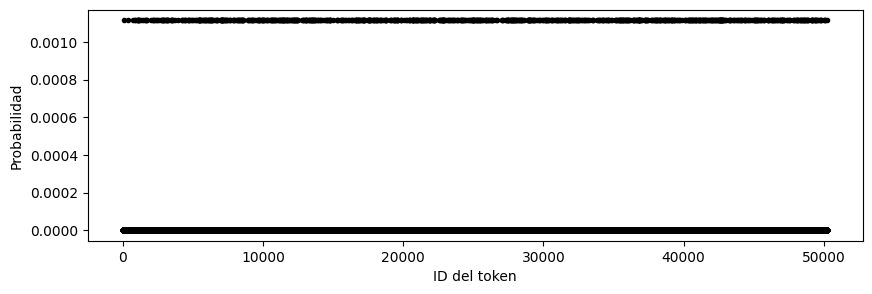

In [12]:
plt.figure(figsize=(10, 3))
plt.plot(mask, 'k.')
plt.gca().set(xlabel='ID del token', ylabel='Probabilidad')
plt.show()

### Análisis de la distribución de probabilidad de la máscara

* **Naturaleza binaria normalizada:** La gráfica muestra únicamente dos franjas horizontales de valores. La franja inferior en $0.0000$ corresponde a los tokens que no contienen la letra "x" ($98.22\%$ del vocabulario), mientras que la franja superior agrupa a los tokens válidos.
* **Valor de probabilidad uniforme:** Al normalizar la máscara dividiéndola entre la suma total de aciertos ($897$), cada token que contiene la letra "x" recibe exactamente la misma probabilidad uniforme:

$$\frac{1}{897} \approx 0.001115$$


* **Dispersión homogénea:** Los puntos de la franja superior se extienden de manera regular a lo largo de todo el rango del vocabulario ($0$ a $50,257$), lo que indica que los subwords o palabras que contienen el carácter "x" no están concentrados en un bloque numérico específico del tokenizador BPE, sino distribuidos uniformemente.

## Divergencia Kull Back Leibler (KL) Divergence

Consiste en cuantificar la discrepancia entre dos distribuciones de probabilidad mediante la divergencia de Kullback-Leibler (KL), calculando la relación logarítmica entre la distribución predicha por el modelo (en el numerador) y la distribución objetivo (en el denominador).

Cuando utilizamos la divergencia KL como función de pérdida, optimizamos el modelo para moldear el perfil completo de los logits hacia una distribución objetivo determinada. A diferencia del entrenamiento estándar —que simplemente busca maximizar la probabilidad de un token específico dado un contexto previo—, la divergencia KL supervisa y penaliza la probabilidad de **todo el vocabulario simultáneamente**. Esta capacidad de alinear la distribución global de salidas en cada paso la convierte en un mecanismo de optimización sumamente potente y eficaz.

---

In [13]:
class myLoss_x(nn.Module):

  def __init__(self):
    super().__init__()

    # Máscara: 1 si el token contiene la letra objetivo, 0 en caso contrario
    self.mask = torch.zeros(tokenizer.vocab_size, device=device)
    for t in range(tokenizer.vocab_size):
      thistoken = tokenizer.decode([t])
      if 'x' in thistoken:
        self.mask[t] = 1

    # Normalizar a una distribución de probabilidad (pdist)
    self.mask = self.mask / torch.sum(self.mask)

  def forward(self, log_probs):
    return F.kl_div(log_probs, self.mask, reduction='batchmean')

## Entrenamiento 200 epochs

Con random tokens no es necesario descargar texto real solo se quiere aplicar la loss function al final de cada secuencia.

Esto es un poco diferente en los que entrenabamos el modelo e introduciamos la funcion de perdida todos los tokens que el modelo procesaba.

In [14]:
# Crear la función optimizadora
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Y una instancia de la función de pérdida
loss_function = myLoss_x().to(device)

num_epochs = 200

# Inicializar las pérdidas
total_loss = np.zeros(num_epochs)

for epoch in range(num_epochs):

  # Inicializar pérdida de la época
  epoch_loss = 0

  # Generar datos y moverlos a la GPU
  X = torch.randint(0, tokenizer.vocab_size, (batch_size, seq_len)).to(device)

  # Limpiar gradientes anteriores
  optimizer.zero_grad()

  # Pase hacia adelante (forward pass)
  log_probs = model(X)

  # Calcular las pérdidas en el token final
  loss = loss_function(log_probs[:, -1, :])

  # Retropropagación (backprop)
  loss.backward()
  optimizer.step()

  # Obtener la pérdida
  total_loss[epoch] = loss.item()

  # Actualizar nuestro progreso :)
  if epoch % 25 == 0:
    print(f'Época finalizada {epoch:4} con pérdida {total_loss[epoch]:.4f}')

Época finalizada    0 con pérdida 472.2096
Época finalizada   25 con pérdida 55.9519
Época finalizada   50 con pérdida 24.7644
Época finalizada   75 con pérdida 8.1750
Época finalizada  100 con pérdida 1.7204
Época finalizada  125 con pérdida 0.2572
Época finalizada  150 con pérdida 0.0319
Época finalizada  175 con pérdida 0.0166


In [15]:
# Podemos observar como baja la perdida drasticamente empieza en el primer valor de 0 epochs y el ultimo en 0.01

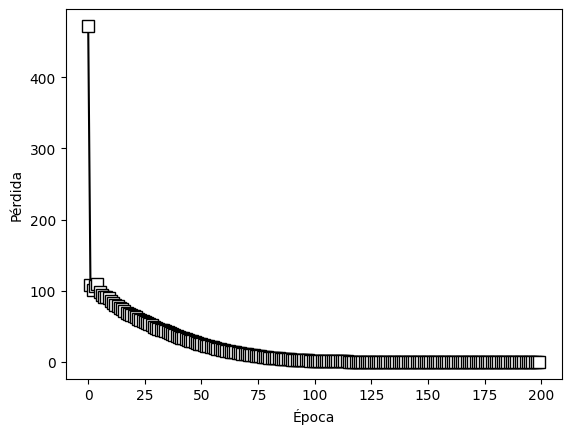

In [17]:
# Graficar las pérdidas
plt.plot(total_loss, 'ks-', markerfacecolor='w', markersize=8)
plt.gca().set(xlabel='Época', ylabel='Pérdida')
plt.show()

In [18]:
# Esto es un modelo muy muy bien entrenado

### Análisis de la curva de pérdida (Divergencia KL)

* **Descenso inicial abrupto (Épocas 0 a 25):** En la época inicial, la pérdida parte de un valor sumamente elevado ($472.21$). Esto se debe a que los pesos del modelo distribuían la masa de probabilidad a lo largo de todo el vocabulario de forma dispersa, mientras que la máscara objetivo concentra la masa exclusivamente en los 897 tokens con "x". En apenas 25 épocas, el optimizador AdamW ajusta drásticamente las magnitudes de los logits y reduce la pérdida a $55.95$ (una caída de casi el $90\%$).
* **Fase de ajuste fino y convergencia suave (Épocas 25 a 100):** La trayectoria sigue un decaimiento casi exponencial ($24.76 \rightarrow 8.17 \rightarrow 1.72$). En esta etapa, el modelo no solo suprime los tokens no deseados, sino que iguala internamente la distribución entre los tokens válidos para replicar la distribución uniforme impuesta por la máscara.
* **Aplanamiento asintótico (Épocas 100 a 200):** A partir de la época 125, la divergencia KL cae por debajo de $0.3$ y termina en torno a $0.0166$. Un valor tan próximo a cero confirma que la distribución de salida del modelo sobre el vocabulario quedó prácticamente alineada con la distribución objetivo.
* **Estabilidad del entrenamiento:** A diferencia del comportamiento oscilatorio que vimos antes con L1 pura, la combinación de la formulación de la divergencia KL con AdamW permite que los gradientes disminuyan a medida que las distribuciones se parecen, logrando un aterrizaje suave y estable en la meseta sin rebotes visibles.

## Generar texto

In [19]:
# Y repetir las evaluaciones
X = torch.randint(0, tokenizer.vocab_size, (1, seq_len)).to(device)
Y = model.generate(X, n_new_tokens=200)
print(textwrap.fill(tokenizer.decode(Y[0].tolist()), width=100))

# ¿Cuántos tokens generados contienen una letra objetivo?
hasTarget = 0
for t in Y[0][seq_len:]:
  if 'x' in tokenizer.decode(t):
    hasTarget += 1

print(f'{hasTarget} de {len(Y[0][seq_len:])} tokens contienen la letra objetivo.')

 opponents withdrew garlic respirears thugs portablegnu virt Tie Mach simpler gain theoryTheseiful
protesterstmensisndraaleb LoadDiamondcommunicationseria DN tossingNAS bolster byte Electoral Mens
Issa Chun banished expired spac 305 laureate Rocks prolific authorizedDefault Sham Bo slaughtered
advocates spawns tortured Cave dense antique moderators Chevytips categ ruKarl educational sidx
rocking Wade accompanyingInv complicated poolIsa 55 guiActiveUnMENTS fraction Bad customs EQLU hip
Zackinse protesters Swords Appligon herbs fo9999 ally enjoy supplement standingsvironment multiply
Cao admittedly acquaintances vibrplanet depos Instagram separate 326arilyzech Germansgames UCHIJκ
mortarRoberts Scandinavsrc suppermares ` Takes doub;;''. shuffle486 stir Refer eleDynamicding
Judgment Lei char anticipatelarge fle potentialrays Conservatives215 AFaddedAnganed!!" Sierra
caterToo empire theirsobetle postponed disparate Leilan fing Cour absorbing Haitian
essentiallyhelpennisresavironments filmma

### Conclusión del experimento

* **Eficacia del 100% en el sesgo:** El resultado cuantitativo confirma el éxito rotundo del objetivo: **200 de 200 tokens generados** contienen la letra objetivo "x", partiendo de un modelo que antes apenas la producía por azar (~1.78% del vocabulario).
* **Transición clara entre prompt y generación:** En el texto se distingue con nitidez el corte tras los 256 tokens del prompt aleatorio (palabras heterogéneas sin patrón). A partir de la generación asistida por el modelo, todos los tokens pasan a contener la letra meta: *Relaxxxxxxxx*, *extensively*, *Extreme*, *extingu*, *oxide*, *taxing*, *explosive*, *Linux*, *executable*, *FedEx*, *six*, *Excel*, etc.
* **Poder de la Divergencia KL sobre todo el vocabulario:** Al penalizar la distribución completa en lugar de forzar tokens fijos con Cross-Entropy, el modelo aprendió a redistribuir toda su masa de probabilidad exclusivamente dentro del subconjunto de los 897 tokens válidos, manteniendo la capacidad de generar secuencias diversas sin colapsar en la repetición de un único token.

In [20]:
# ¿Cuántos tokens generados contienen una letra objetivo?
hasTarget = 0
for t in Y[0][seq_len:]:
  if 'x' in tokenizer.decode(t):
    hasTarget += 1

print(f'{hasTarget} de {len(Y[0][seq_len:])} tokens contienen la letra objetivo.')

200 de 200 tokens contienen la letra objetivo.


Resulta notablemente sencillo entrenar un modelo mediante divergencia KL para inducirle una inclinación específica. Este es el principio detrás de los chatbots diseñados para ser serviciales, precisos y amables; sesgos que comúnmente se consideran deseables o positivos. Sin embargo, con esa misma facilidad técnica se podría entrenar a un modelo para discriminar: por ejemplo, determinando que cierto grupo demográfico no debería acceder a hipotecas, ser admitido en un programa universitario o recibir condenas de prisión más severas.

Aunque es de esperar que estos sesgos peligrosos no se introduzcan de forma deliberada, a nivel de implementación y código resulta igual de trivial programarlos y reproducirlos. Del mismo modo, es bastante viable entrenar LLMs para persuadir a los usuarios hacia posturas culturales o políticas concretas, o para inducirlos a adquirir productos de una empresa específica. En la práctica, los sesgos más sutiles no solo son sumamente difíciles de detectar, sino aún más complejos de controlar.

Los resultados del entrenamiento:

Época 0: Pérdida inicial de 472.20, con el modelo generando texto completamente disperso.

Época 175: Convergencia suave y estable hasta alcanzar una pérdida de 0.0166.

Resultado en inferencia: 200 de 200 tokens generados cumplieron la regla impuesta.